In [1]:
!git clone https://github.com/westermo/test-system-performance-dataset.git

Cloning into 'test-system-performance-dataset'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 32 (delta 0), reused 1 (delta 0), pack-reused 29 (from 1)
Receiving objects: 100% (32/32), 82.02 MiB | 9.24 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Updating files: 100% (25/25), done.


In [2]:
!head test-system-performance-dataset/data/system-1.csv

timestamp,load-1m,load-5m,load-15m,sys-mem-swap-total,sys-mem-swap-free,sys-mem-free,sys-mem-cache,sys-mem-buffered,sys-mem-available,sys-mem-total,sys-fork-rate,sys-interrupt-rate,sys-context-switch-rate,sys-thermal,disk-io-time,disk-bytes-read,disk-bytes-written,disk-io-read,disk-io-write,cpu-iowait,cpu-system,cpu-user,server-up
0,0.22,0.18,0.18,16953372672,16953372672,2071302144,10307330048,1937584128,15328792576,16662700032,0.8,970.15,2217.2000000000003,1.6,0.0076000000000931,0.0,16588.8,0.0,2.1,0.0095000000000254,0.02400000000016,0.0405000000006111,2
30,0.26,0.19,0.18,16953372672,16953372672,2072969216,10307371008,1937584128,15330496512,16662700032,0.95,1081.55,2693.7000000000003,0.0,0.0060000000001309,0.0,14745.6,0.0,1.5,0.0125,0.0270000000005893,0.0474999999994906,2
60,0.16,0.17,0.18,16953372672,16953372672,2071818240,10307375104,1937584128,15329353728,16662700032,0.8,995.4,2275.35,0.0,0.0133999999998195,0.0,15564.8,0.0,1.65,0.0134999999999308,0.0254999999999199,0.02599999999983

In [3]:
import pandas as pd

df = pd.read_csv("test-system-performance-dataset/data/system-6.csv")


df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')


df = df.sort_values('timestamp').reset_index(drop=True)


In [4]:

exclude_cols = ['timestamp', 'server-up']


signal_cols = [c for c in df.columns if c not in exclude_cols]

X = df[signal_cols]


In [5]:

X.isna().sum()


,0
load-1m,0
load-5m,0
load-15m,0
sys-mem-swap-total,0
sys-mem-swap-free,0
sys-mem-free,0
sys-mem-cache,0
sys-mem-buffered,0
sys-mem-available,0
sys-mem-total,0


In [6]:



from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
X_scaled.shape


(86401, 22)

In [8]:
import numpy as np

WINDOW_SIZE = 30

def create_windows(data, window_size):
    windows = []
    for i in range(len(data) - window_size + 1):
        windows.append(data[i:i+window_size])
    return np.array(windows)

X_windows = create_windows(X_scaled, WINDOW_SIZE)


In [9]:
X_windows.shape

(86372, 30, 22)

In [10]:
import numpy as np


X_win_mean = X_windows.mean(axis=1)


mu = X_win_mean.mean(axis=0)
sigma = X_win_mean.std(axis=0)
epsilon = 1e-8
z_scores = np.abs((X_win_mean - mu) / (sigma + epsilon))


baseline_score = z_scores.max(axis=1)


threshold = np.percentile(baseline_score, 95)

baseline_anomaly = baseline_score > threshold


In [11]:
np.isnan(z_scores).sum()


np.int64(0)

Total windows: 86372
Anomalous windows: 4318
Normal windows: 82054


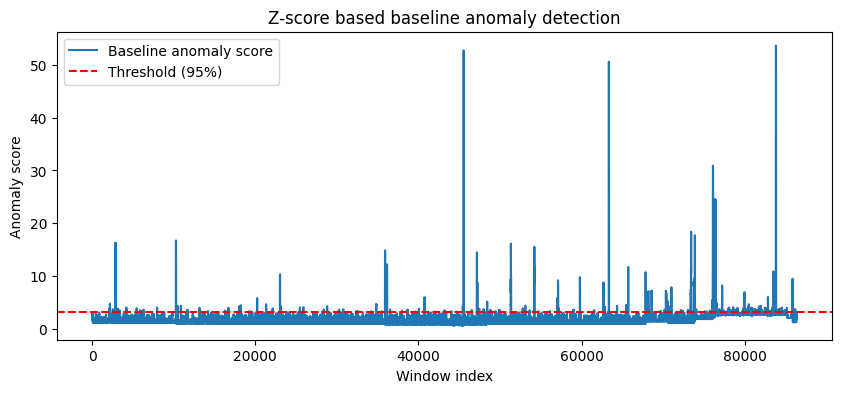

In [12]:
import matplotlib.pyplot as plt
print("Total windows:", len(baseline_anomaly))
print("Anomalous windows:", baseline_anomaly.sum())
print("Normal windows:", (~baseline_anomaly).sum())


plt.figure(figsize=(10,4))
plt.plot(baseline_score, label="Baseline anomaly score")
plt.axhline(threshold, color='red', linestyle='--', label='Threshold (95%)')
plt.legend()
plt.title("Z-score based baseline anomaly detection")
plt.xlabel("Window index")
plt.ylabel("Anomaly score")
plt.show()


In [13]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso.fit(X_win_mean)

iso_score = -iso.score_samples(X_win_mean)
iso_anomaly = iso_score > np.percentile(iso_score, 95)


Baseline anomalies: 4318
Isolation Forest anomalies: 4319
Combined anomalies: 6398


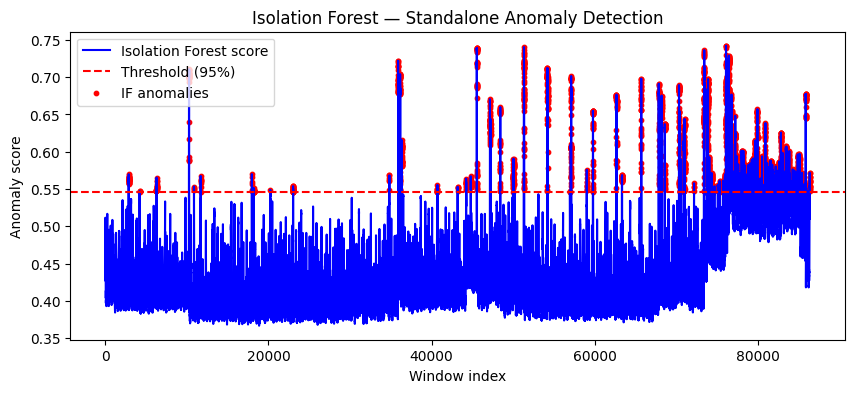

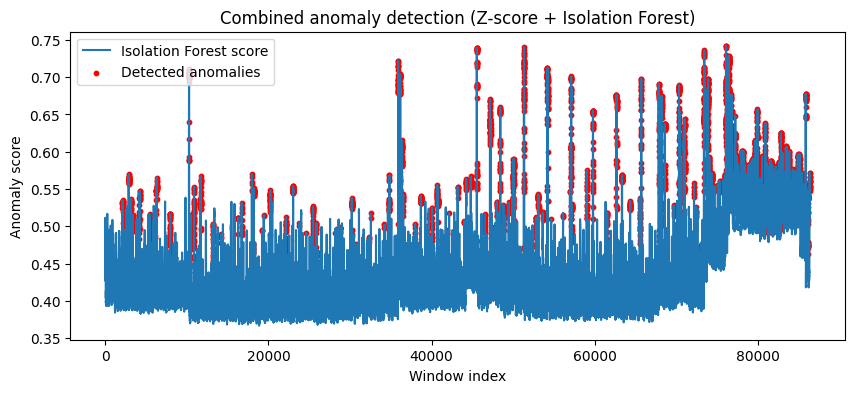

In [22]:
combined_anomaly = baseline_anomaly | iso_anomaly

print("Baseline anomalies:", baseline_anomaly.sum())
print("Isolation Forest anomalies:", iso_anomaly.sum())
print("Combined anomalies:", combined_anomaly.sum())

# Standalone IF plot
plt.figure(figsize=(10,4))
plt.plot(iso_score, label="Isolation Forest score", color='blue')
plt.axhline(np.percentile(iso_score, 95), color='red', linestyle='--', label='Threshold (95%)')
plt.scatter(
    np.where(iso_anomaly)[0],
    iso_score[iso_anomaly],
    color='red', s=10, label="IF anomalies"
)
plt.legend()
plt.title("Isolation Forest — Standalone Anomaly Detection")
plt.xlabel("Window index")
plt.ylabel("Anomaly score")
plt.show()

# Combined plot
plt.figure(figsize=(10,4))
plt.plot(iso_score, label="Isolation Forest score")
plt.scatter(
    np.where(combined_anomaly)[0],
    iso_score[combined_anomaly],
    color='red', s=10, label="Detected anomalies"
)
plt.legend()
plt.title("Combined anomaly detection (Z-score + Isolation Forest)")
plt.xlabel("Window index")
plt.ylabel("Anomaly score")
plt.show()

=== Overlap Analysis: Z-score vs Isolation Forest ===
Only Z-score flagged:          2079
Only Isolation Forest flagged: 2080
Both agreed (high confidence): 2239
Total combined:                6398


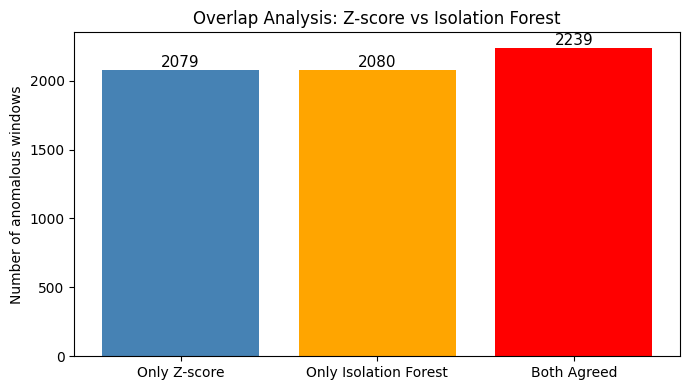

In [21]:
only_zscore = baseline_anomaly & ~iso_anomaly
only_iso    = iso_anomaly & ~baseline_anomaly
both_agree  = baseline_anomaly & iso_anomaly

print("=== Overlap Analysis: Z-score vs Isolation Forest ===")
print(f"Only Z-score flagged:          {only_zscore.sum()}")
print(f"Only Isolation Forest flagged: {only_iso.sum()}")
print(f"Both agreed (high confidence): {both_agree.sum()}")
print(f"Total combined:                {combined_anomaly.sum()}")

categories = ['Only Z-score', 'Only Isolation Forest', 'Both Agreed']
counts = [only_zscore.sum(), only_iso.sum(), both_agree.sum()]
colors = ['steelblue', 'orange', 'red']

plt.figure(figsize=(7,4))
bars = plt.bar(categories, counts, color=colors)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(count), ha='center', fontsize=11)
plt.title("Overlap Analysis: Z-score vs Isolation Forest")
plt.ylabel("Number of anomalous windows")
plt.tight_layout()
plt.show()

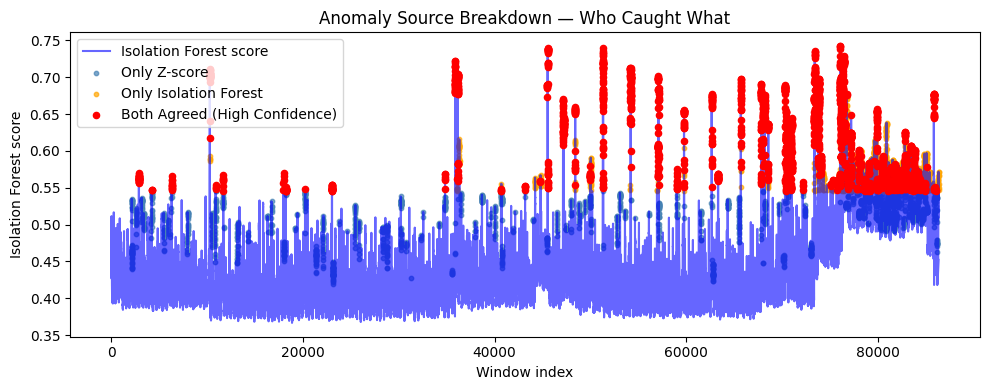

In [23]:
plt.figure(figsize=(10,4))
plt.plot(iso_score, label="Isolation Forest score", color='blue', alpha=0.6)
plt.scatter(
    np.where(only_zscore)[0],
    iso_score[only_zscore],
    color='steelblue', s=10, label="Only Z-score", alpha=0.7
)
plt.scatter(
    np.where(only_iso)[0],
    iso_score[only_iso],
    color='orange', s=10, label="Only Isolation Forest", alpha=0.7
)
plt.scatter(
    np.where(both_agree)[0],
    iso_score[both_agree],
    color='red', s=20, label="Both Agreed (High Confidence)", zorder=5
)
plt.legend()
plt.title("Anomaly Source Breakdown — Who Caught What")
plt.xlabel("Window index")
plt.ylabel("Isolation Forest score")
plt.tight_layout()
plt.show()

Baseline anomalies: 4318
Isolation Forest anomalies: 4319
Combined anomalies: 6398


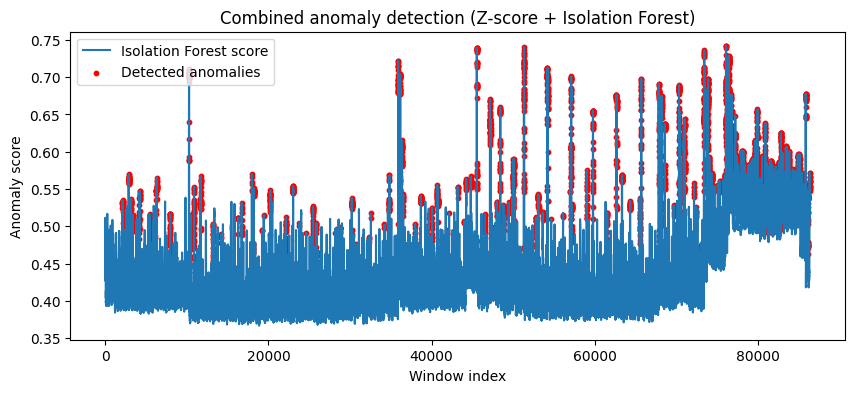

In [14]:

combined_anomaly = baseline_anomaly | iso_anomaly

print("Baseline anomalies:", baseline_anomaly.sum())
print("Isolation Forest anomalies:", iso_anomaly.sum())
print("Combined anomalies:", combined_anomaly.sum())
plt.figure(figsize=(10,4))
plt.plot(iso_score, label="Isolation Forest score")
plt.scatter(
    np.where(combined_anomaly)[0],
    iso_score[combined_anomaly],
    color='red',
    s=10,
    label="Detected anomalies"
)
plt.legend()
plt.title("Combined anomaly detection (Z-score + Isolation Forest)")
plt.xlabel("Window index")
plt.ylabel("Anomaly score")
plt.show()


In [15]:

import pandas as pd
import numpy as np


X_win_df = pd.DataFrame(X_win_mean)


roll_size = 20

rolling_mean = X_win_df.rolling(window=roll_size).mean()
rolling_std = X_win_df.rolling(window=roll_size).std()


roll_score = np.abs(X_win_df - rolling_mean) / (rolling_std + 1e-8)


roll_anomaly_score = roll_score.max(axis=1)


roll_threshold = np.nanpercentile(roll_anomaly_score, 95)

roll_anomaly = roll_anomaly_score > roll_threshold


Rolling-stat anomalies: 4318


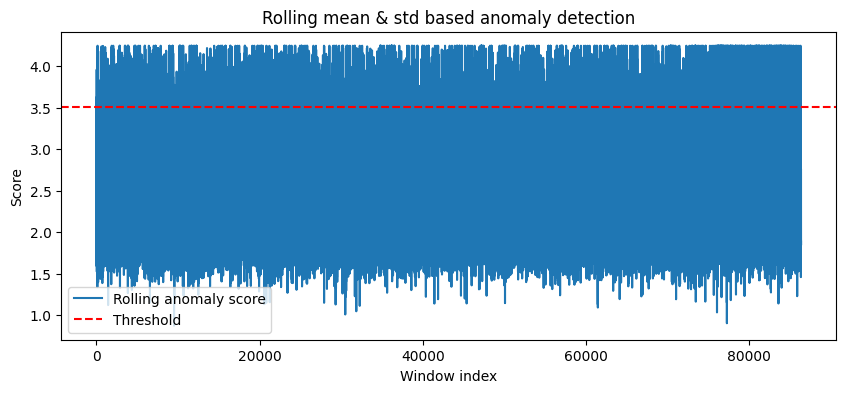

In [16]:
print("Rolling-stat anomalies:", roll_anomaly.sum())

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(roll_anomaly_score, label="Rolling anomaly score")
plt.axhline(roll_threshold, color='red', linestyle='--', label="Threshold")
plt.legend()
plt.title("Rolling mean & std based anomaly detection")
plt.xlabel("Window index")
plt.ylabel("Score")
plt.show()


In [17]:
import pickle

with open("anomaly_results.pkl", "wb") as f:
    pickle.dump({
        "baseline_anomaly": baseline_anomaly,
        "roll_anomaly": roll_anomaly,
        "iso_anomaly": iso_anomaly,
        "combined_anomaly": combined_anomaly
    }, f)


In [18]:
plt.savefig("rolling_anomaly_plot.png", dpi=300, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>